In [1]:
dados_simetrico = [4, 5, 6, 5, 4, 6, 5, 5, 6, 4]

dados_assimetrico_direita = [2, 3, 3, 4, 3, 2, 3, 4, 10]

dados_assimetrico_esquerda = [10, 9, 8, 9, 10, 8, 9, 2]

dados_com_outlier = [5, 6, 5, 6, 5, 6, 5, 20]

dados_dispersao_maior = [1, 4, 7, 10, 13, 16]

In [4]:
import matplotlib.pyplot as plt 
import matplotlib.ticker as ticker

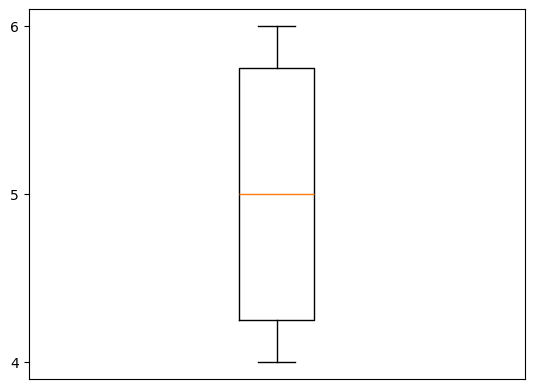

In [5]:
plt.boxplot(dados_simetrico)

plt.xticks([])
plt.gca().yaxis.set_major_locator(ticker.MaxNLocator(integer=True))


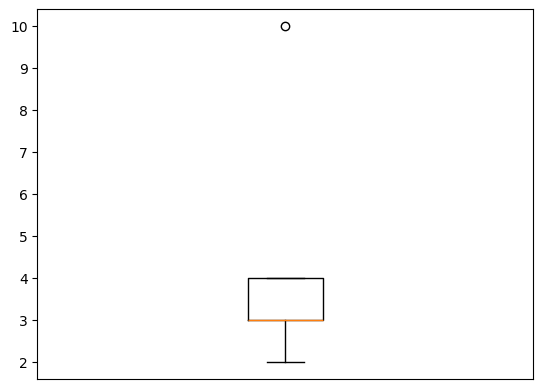

In [6]:
plt.boxplot(dados_assimetrico_direita)

plt.xticks([])
plt.gca().yaxis.set_major_locator(ticker.MaxNLocator(integer=True))

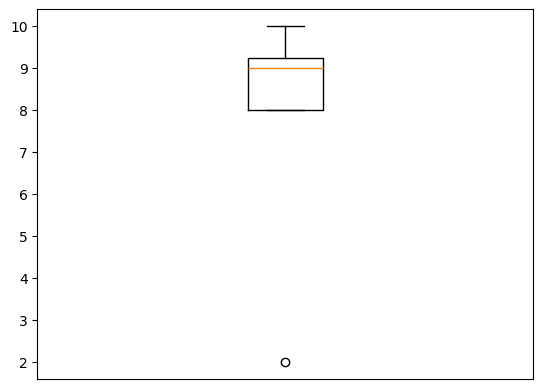

In [7]:
plt.boxplot(dados_assimetrico_esquerda)

plt.xticks([])
plt.gca().yaxis.set_major_locator(ticker.MaxNLocator(integer=True))

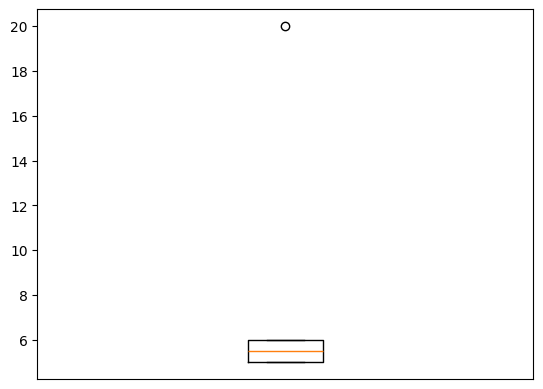

In [8]:
plt.boxplot(dados_com_outlier)

plt.xticks([])
plt.gca().yaxis.set_major_locator(ticker.MaxNLocator(integer=True))

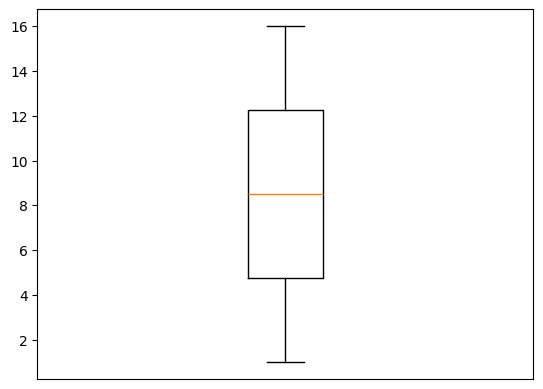

In [9]:
plt.boxplot(dados_dispersao_maior)

plt.xticks([])
plt.gca().yaxis.set_major_locator(ticker.MaxNLocator(integer=True))

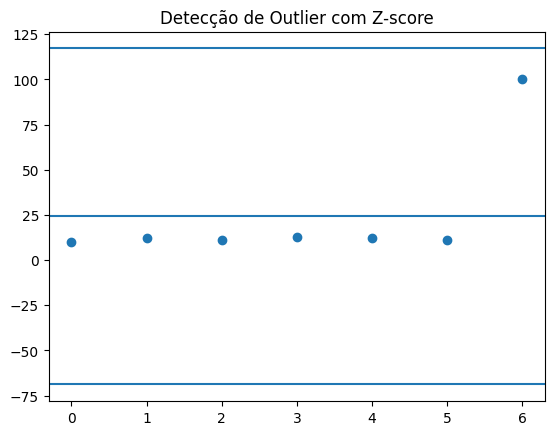

In [10]:
import numpy as np

dados = np.array([10, 12, 11, 13, 12, 11, 100])

import matplotlib.pyplot as plt

media = np.mean(dados)
desvio = np.std(dados)

limite_superior = media + 3 * desvio
limite_inferior = media - 3 * desvio

plt.scatter(range(len(dados)), dados)
plt.axhline(media)
plt.axhline(limite_superior)
plt.axhline(limite_inferior)

plt.title("Detecção de Outlier com Z-score")
plt.show()

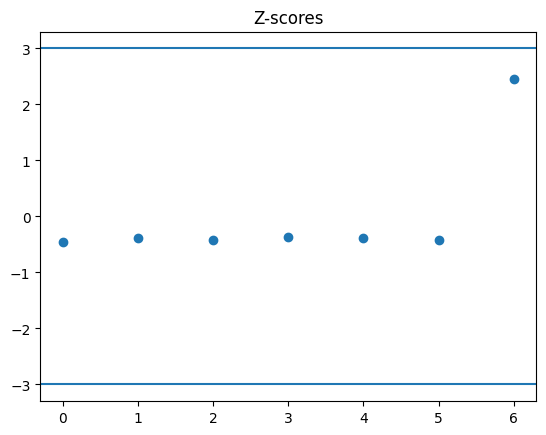

In [11]:
z_scores = (dados - media) / desvio

plt.scatter(range(len(z_scores)), z_scores)
plt.axhline(3)
plt.axhline(-3)

plt.title("Z-scores")
plt.show()

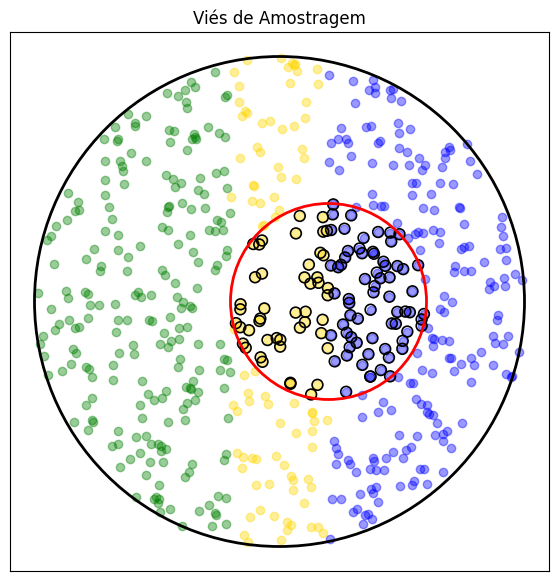

In [8]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# -----------------------
# 1) Gerar população no círculo grande
# -----------------------
n = 600
R_pop = 10

theta = np.random.uniform(0, 2*np.pi, n)
r = R_pop * np.sqrt(np.random.uniform(0, 1, n))

x = r * np.cos(theta)
y = r * np.sin(theta)

labels = np.empty(n, dtype=object)

labels[x < -2] = "verde"
labels[(x >= -2) & (x <= 2)] = "amarelo"
labels[x > 2] = "azul"

# -----------------------
# 2) Definir amostra enviesada (círculo menor)
# -----------------------
R_sample = 4
center_sample = (2, 0)

mask_sample = (x - center_sample[0])**2 + (y - center_sample[1])**2 <= R_sample**2

# -----------------------
# 3) Plot
# -----------------------
fig, ax = plt.subplots(figsize=(7,7))

# população
ax.scatter(x[labels=="verde"], y[labels=="verde"], color="green", alpha=0.4)
ax.scatter(x[labels=="amarelo"], y[labels=="amarelo"], color="gold", alpha=0.4)
ax.scatter(x[labels=="azul"], y[labels=="azul"], color="blue", alpha=0.4)

# destacar amostra
ax.scatter(x[mask_sample], y[mask_sample],
           edgecolor="black", facecolor="none",
           s=60, linewidth=1.2)

# círculo população
circle_pop = plt.Circle((0, 0), R_pop, color='black', fill=False, linewidth=2)
ax.add_patch(circle_pop)

# círculo amostra
circle_sample = plt.Circle(center_sample, R_sample, color='red', fill=False, linewidth=2)
ax.add_patch(circle_sample)

ax.set_aspect("equal")
ax.set_xticks([])
ax.set_yticks([])
ax.set_title("Viés de Amostragem")

plt.show()

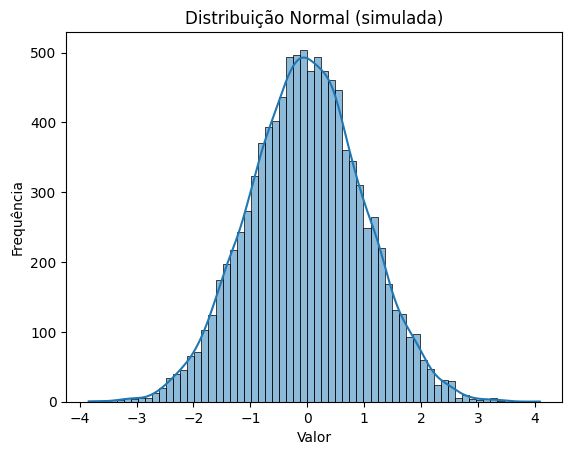

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# gerar 1000 valores com média 0 e desvio padrão 1
dados = np.random.normal(loc=0, scale=1, size=10000)

# plot
sns.histplot(dados, kde=True)
plt.title("Distribuição Normal (simulada)")
plt.xlabel("Valor")
plt.ylabel("Frequência")
plt.show()

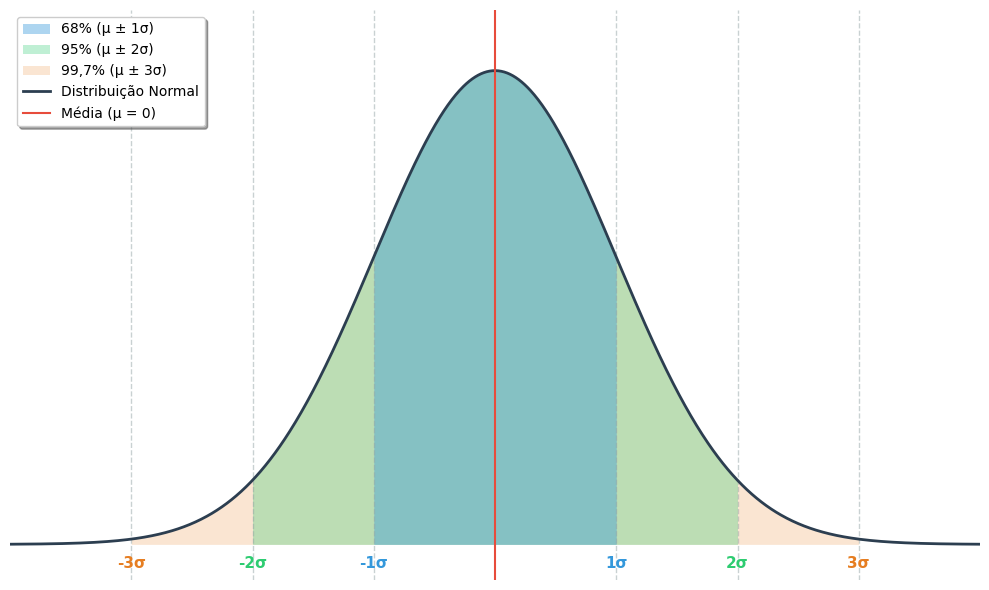

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# parâmetros da distribuição
mu = 0        # média
sigma = 1     # desvio padrão

# eixo x
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 1000)

# função densidade
y = norm.pdf(x, mu, sigma)

# criar figura
plt.figure(figsize=(10, 6))

# cores para cada intervalo (usadas tanto nas áreas quanto nos labels)
cor_68 = '#3498DB'  # azul
cor_95 = '#2ECC71'  # verde
cor_99 = '#E67E22'  # laranja

# Primeiro: área de 99,7% (a maior, por baixo de todas)
x_fill_99 = np.linspace(mu - 3*sigma, mu + 3*sigma, 1000)
y_fill_99 = norm.pdf(x_fill_99, mu, sigma)
plt.fill_between(x_fill_99, y_fill_99, alpha=0.2, color=cor_99, linewidth=0, label='_nolegend_')

# Depois: área de 95% (do meio, por cima da laranja apenas onde se sobrepõe)
x_fill_95 = np.linspace(mu - 2*sigma, mu + 2*sigma, 1000)
y_fill_95 = norm.pdf(x_fill_95, mu, sigma)
plt.fill_between(x_fill_95, y_fill_95, alpha=0.3, color=cor_95, linewidth=0, label='_nolegend_')

# Por último: área de 68% (a menor, por cima de todas)
x_fill_68 = np.linspace(mu - sigma, mu + sigma, 1000)
y_fill_68 = norm.pdf(x_fill_68, mu, sigma)
plt.fill_between(x_fill_68, y_fill_68, alpha=0.4, color=cor_68, linewidth=0, label='_nolegend_')

# linhas verticais para os limites
for k in [1, 2, 3]:
    plt.axvline(mu + k*sigma, linestyle='--', color='#95A5A6', alpha=0.5, linewidth=1)
    plt.axvline(mu - k*sigma, linestyle='--', color='#95A5A6', alpha=0.5, linewidth=1)
    
    # definir cores diferentes para cada label baseado no valor de k
    if k == 1:
        cor_label = cor_68
    elif k == 2:
        cor_label = cor_95
    else:  # k == 3
        cor_label = cor_99
    
    # adicionar rótulos para os limites com as cores correspondentes
    plt.text(mu + k*sigma, -0.02, f'{k}σ', ha='center', fontsize=11, color=cor_label, fontweight='bold')
    plt.text(mu - k*sigma, -0.02, f'-{k}σ', ha='center', fontsize=11, color=cor_label, fontweight='bold')

# curva normal (por cima das áreas)
plt.plot(x, y, linewidth=2, color='#2C3E50')

# média (por cima das áreas)
plt.axvline(mu, color='#E74C3C', linestyle='-', linewidth=1.5)

# criar legenda personalizada com as MESMAS cores das áreas
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

legend_elements = [
    Patch(facecolor=cor_68, alpha=0.4, edgecolor='none', label='68% (μ ± 1σ)'),
    Patch(facecolor=cor_95, alpha=0.3, edgecolor='none', label='95% (μ ± 2σ)'),
    Patch(facecolor=cor_99, alpha=0.2, edgecolor='none', label='99,7% (μ ± 3σ)'),
    Line2D([0], [0], color='#2C3E50', linewidth=2, label='Distribuição Normal'),
    Line2D([0], [0], color='#E74C3C', linewidth=1.5, label='Média (μ = 0)')
]

plt.legend(handles=legend_elements, loc='upper left', frameon=True, fancybox=True, shadow=True, fontsize=10)

# remover números dos eixos
plt.xticks([])
plt.yticks([])

# remover grids
plt.grid(False)

# remover labels dos eixos
plt.xlabel("")
plt.ylabel("")

# ajustar limites
plt.ylim(-0.03, 0.45)
plt.xlim(mu - 4*sigma, mu + 4*sigma)

# remover as bordas do gráfico (spines)
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)

plt.tight_layout()
plt.show()

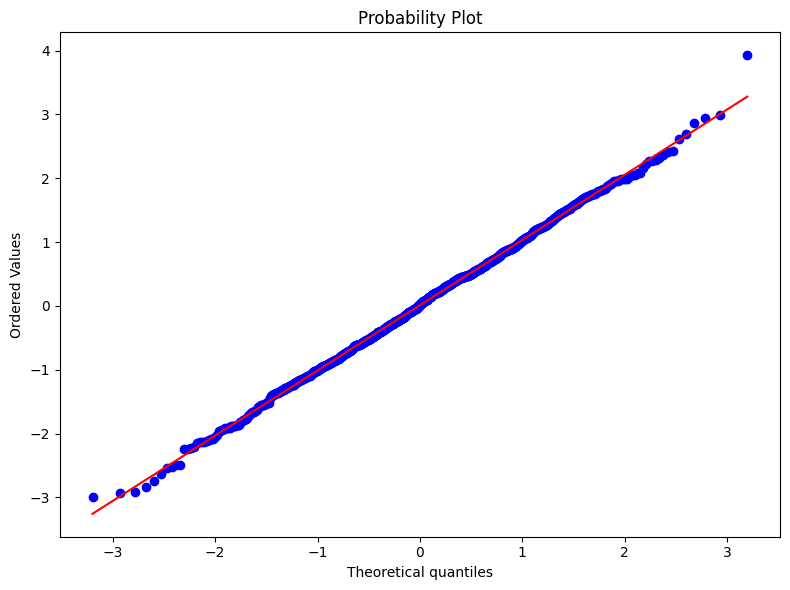

In [8]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

# Criando uma figura com um subplot
fig, ax = plt.subplots(figsize=(8, 6))

# Gerando amostra normal
norm_sample = stats.norm.rvs(size=1000)  # NOTA: é rvs, não rsv

# Fazendo o QQ plot direto no ax
stats.probplot(norm_sample, plot=ax)

plt.tight_layout()
plt.show()

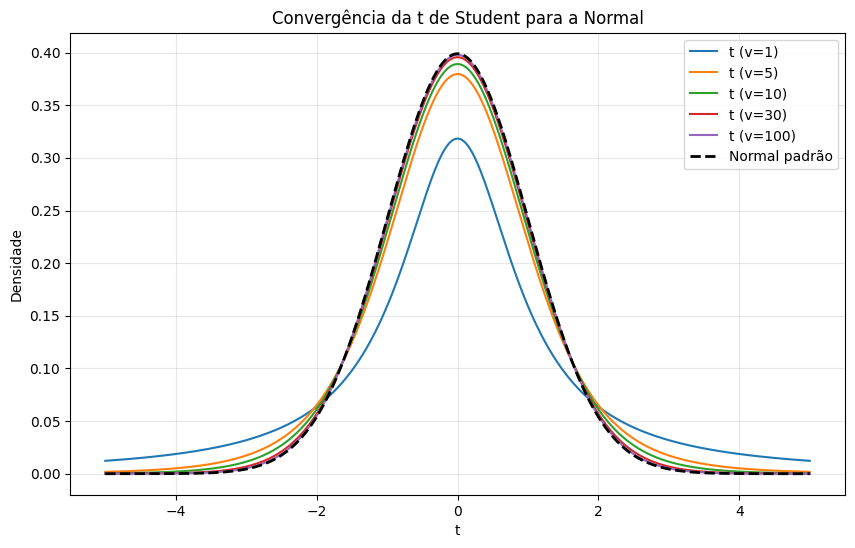

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import t, norm

# Intervalo do eixo x
x = np.linspace(-5, 5, 1000)

# Graus de liberdade
dfs = [1, 5, 10, 30, 100]

plt.figure(figsize=(10, 6))

# Plot da distribuição t para diferentes v
for df in dfs:
    plt.plot(x, t.pdf(x, df), label=f"t (v={df})")

# Plot da normal padrão
plt.plot(x, norm.pdf(x), 'k--', linewidth=2, label="Normal padrão")

plt.title("Convergência da t de Student para a Normal")
plt.xlabel("t")
plt.ylabel("Densidade")
plt.legend()
plt.grid(alpha=0.3)

plt.show()